In [1]:
import os
import json
import re
import time
import pandas as pd
import numpy as np
from groq import Groq
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

# Load data
df_resolved = pd.read_pickle("../data/processed/df_resolved.pkl")

# Attach desc_clean (replicate cleaning from NB07)
import re as _re

def clean_desc(text):
    if not isinstance(text, str):
        return None
    text = text.lower()
    boilerplate = [
        r"borrower added on \d{2}/\d{2}/\d{2,4}\s*>",
        r"borrower added on \d{2}/\d{2}/\d{2,4}",
        r"<br\s*/?>",
        r"&amp;",
        r"&nbsp;",
    ]
    for pattern in boilerplate:
        text = _re.sub(pattern, " ", text)
    text = _re.sub(r"http\S+|www\.\S+", " ", text)
    text = _re.sub(r"[^a-z0-9\s]", " ", text)
    text = _re.sub(r"\s+", " ", text).strip()
    if len(text.split()) < 3:
        return None
    return text

df_resolved["desc_clean"] = df_resolved["desc"].apply(clean_desc)
desc_df = df_resolved[df_resolved["desc_clean"].notna()].copy()

print(f"Loans with clean descriptions: {len(desc_df):,}")
print(f"Default rate: {desc_df['default_flag'].mean()*100:.1f}%")

Loans with clean descriptions: 120,134
Default rate: 15.5%


In [2]:
EXTRACTION_PROMPT = """You are a credit risk analyst reviewing a loan application description written by a borrower.

Extract exactly these five signals from the description and return ONLY a valid JSON object — no explanation, no markdown, no extra text.

Fields to extract:
- financial_distress_flag: 1 if the borrower mentions being behind on payments, struggling financially, facing hardship, or needing urgent help. 0 otherwise.
- purpose_clarity: Score 1-5. 1 = vague or no purpose stated. 5 = very specific, concrete purpose with amounts or plan.
- income_stability_mention: 1 if the borrower mentions stable employment, steady income, long tenure at job, or profession. 0 otherwise.
- repayment_confidence: Score 1-5. 1 = no mention of ability to repay. 5 = explicit repayment plan with timeline or amounts.
- overall_sentiment: "positive", "neutral", or "negative" — the overall tone of the description.

Return format (strictly):
{{"financial_distress_flag": <0 or 1>, "purpose_clarity": <1-5>, "income_stability_mention": <0 or 1>, "repayment_confidence": <1-5>, "overall_sentiment": "<positive|neutral|negative>"}}

Borrower description:
{description}"""

import requests

def extract_signals(description):
    prompt = EXTRACTION_PROMPT.format(description=description)
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "llama3.2:3b",
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0}
            },
            timeout=30
        )
        raw = response.json()["response"].strip()

        # Extract JSON even if model wraps it in extra text
        match = re.search(r'\{.*\}', raw, re.DOTALL)
        if not match:
            return None, raw, "No JSON found in response"
        parsed = json.loads(match.group())
        return parsed, raw, None
    except json.JSONDecodeError as e:
        return None, raw, f"JSON parse error: {e}"
    except Exception as e:
        return None, None, f"API error: {e}"

# Single test
test_desc = "I have been working as a nurse for 12 years and have a stable income. I want to consolidate my three credit cards with a total balance of $18,000 into one lower monthly payment."
result, raw, error = extract_signals(test_desc)

print("INPUT:")
print(test_desc)
print("\nRAW OUTPUT:")
print(raw)
print("\nPARSED:")
print(json.dumps(result, indent=2) if result else f"FAILED: {error}")

INPUT:
I have been working as a nurse for 12 years and have a stable income. I want to consolidate my three credit cards with a total balance of $18,000 into one lower monthly payment.

RAW OUTPUT:
{"financial_distress_flag": 0, "purpose_clarity": 5, "income_stability_mention": 1, "repayment_confidence": 5, "overall_sentiment": "positive"}

PARSED:
{
  "financial_distress_flag": 0,
  "purpose_clarity": 5,
  "income_stability_mention": 1,
  "repayment_confidence": 5,
  "overall_sentiment": "positive"
}


In [9]:
print(desc_df.columns.tolist())
print(desc_df.shape)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [10]:
sample_50 = desc_df.sample(50, random_state=42).copy()

print(f"Sample size: {len(sample_50)}")
print(f"Default rate: {sample_50['default_flag'].mean()*100:.1f}%")
print(f"Grade distribution:\n{sample_50['grade'].value_counts().sort_index()}")

Sample size: 50
Default rate: 20.0%
Grade distribution:
grade
A     9
B    19
C    12
D     6
E     4
Name: count, dtype: int64


In [17]:
# Simple random sample — stratification not needed at 50 loans
sample_50 = desc_df.sample(50, random_state=42).copy()

print(f"Sample size: {len(sample_50)}")
print(f"Default rate: {sample_50['default_flag'].mean()*100:.1f}%")
print(f"Grade distribution:\n{sample_50['grade'].value_counts().sort_index()}")

# Run extraction
results = []
failures = []

for i, (idx, row) in enumerate(sample_50.iterrows()):
    parsed, raw, error = extract_signals(row["desc_clean"])
    
    if parsed:
        parsed["loan_idx"]     = idx
        parsed["default_flag"] = row["default_flag"]
        parsed["grade"]        = row["grade"]
        results.append(parsed)
    else:
        failures.append({"loan_idx": idx, "raw": raw, "error": error})
    
    # Rate limit protection
    time.sleep(0.3)
    
    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/50 — successes: {len(results)}, failures: {len(failures)}")

# Results
parse_rate = len(results) / len(sample_50) * 100
print(f"\n{'='*50}")
print(f"PARSE SUCCESS RATE: {parse_rate:.1f}%  ({len(results)}/50)")
print(f"FAILURES:           {len(failures)}")
print(f"{'='*50}")

if failures:
    print("\nFAILURE SAMPLES:")
    for f in failures[:3]:
        print(f"\n  Error: {f['error']}")
        print(f"  Raw:   {f['raw']}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nEXTRACTED SIGNALS PREVIEW:")
print(results_df.drop(columns=["loan_idx"]).describe())

Sample size: 50
Default rate: 20.0%
Grade distribution:
grade
A     9
B    19
C    12
D     6
E     4
Name: count, dtype: int64
  Processed 10/50 — successes: 10, failures: 0
  Processed 20/50 — successes: 20, failures: 0
  Processed 30/50 — successes: 30, failures: 0
  Processed 40/50 — successes: 40, failures: 0
  Processed 50/50 — successes: 50, failures: 0

PARSE SUCCESS RATE: 100.0%  (50/50)
FAILURES:           0

EXTRACTED SIGNALS PREVIEW:
       financial_distress_flag  purpose_clarity  income_stability_mention  \
count                50.000000        50.000000                 50.000000   
mean                  0.560000         3.540000                  0.120000   
std                   0.501427         1.798072                  0.328261   
min                   0.000000         1.000000                  0.000000   
25%                   0.000000         1.000000                  0.000000   
50%                   1.000000         5.000000                  0.000000   
75%        

In [14]:
print("=" * 50)
print("SIGNAL VALIDATION — DIRECTIONAL CHECK")
print("=" * 50)

signals = ["financial_distress_flag", "purpose_clarity", 
           "income_stability_mention", "repayment_confidence"]

for col in signals:
    default_mean     = results_df[results_df["default_flag"] == 1][col].mean()
    non_default_mean = results_df[results_df["default_flag"] == 0][col].mean()
    
    # Expected direction
    if col == "financial_distress_flag":
        expected = "default > non-default"
        correct  = default_mean > non_default_mean
    else:
        expected = "default < non-default"
        correct  = default_mean < non_default_mean
    
    status = "CORRECT" if correct else "INVERTED"
    print(f"\n{col}")
    print(f"  Non-default mean: {non_default_mean:.3f}")
    print(f"  Default mean:     {default_mean:.3f}")
    print(f"  Expected:         {expected}")
    print(f"  Status:           {status}")

# Sentiment breakdown
print("\n\nSENTIMENT BY DEFAULT STATUS:")
print(pd.crosstab(results_df["overall_sentiment"], 
                  results_df["default_flag"], 
                  normalize="columns").round(3))

SIGNAL VALIDATION — DIRECTIONAL CHECK

financial_distress_flag
  Non-default mean: 0.500
  Default mean:     0.700
  Expected:         default > non-default
  Status:           CORRECT

purpose_clarity
  Non-default mean: 3.375
  Default mean:     2.800
  Expected:         default < non-default
  Status:           CORRECT

income_stability_mention
  Non-default mean: 0.125
  Default mean:     0.100
  Expected:         default < non-default
  Status:           CORRECT

repayment_confidence
  Non-default mean: 2.900
  Default mean:     2.100
  Expected:         default < non-default
  Status:           CORRECT


SENTIMENT BY DEFAULT STATUS:
default_flag           0    1
overall_sentiment            
negative           0.250  0.4
neutral            0.275  0.3
positive           0.475  0.3


In [19]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

# Clear checkpoint
if os.path.exists("../data/processed/llm_extraction_checkpoint.pkl"):
    os.remove("../data/processed/llm_extraction_checkpoint.pkl")
    print("Checkpoint cleared — starting fresh")

# Reduce to 5,000 loans — sufficient for signal validation and model training
pos = desc_df[desc_df["default_flag"] == 1].sample(775, random_state=42)
neg = desc_df[desc_df["default_flag"] == 0].sample(4225, random_state=42)
batch_df = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Batch size:   {len(batch_df):,}")
print(f"Default rate: {batch_df['default_flag'].mean()*100:.1f}%")

# Thread-safe containers
lock           = threading.Lock()
batch_results  = []
batch_failures = []
CHECKPOINT_PATH = "../data/processed/llm_extraction_checkpoint.pkl"

def process_row(args):
    idx, row = args
    parsed, raw, error = extract_signals(row["desc_clean"])
    if parsed:
        parsed["loan_idx"]     = idx
        parsed["default_flag"] = row["default_flag"]
        parsed["grade"]        = row["grade"]
        parsed["desc_clean"]   = row["desc_clean"]
        return "success", parsed
    else:
        return "failure", {"idx": idx, "error": error, "raw": raw}

print("\nStarting parallel extraction (4 workers)...")
start_time = time.time()

rows = [(i, row) for i, (_, row) in enumerate(batch_df.iterrows())]

with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(process_row, r): r for r in rows}
    
    for completed, future in enumerate(as_completed(futures)):
        status, data = future.result()
        with lock:
            if status == "success":
                batch_results.append(data)
            else:
                batch_failures.append(data)
        
        if (completed + 1) % 500 == 0:
            pd.DataFrame(batch_results).to_pickle(CHECKPOINT_PATH)
            elapsed   = time.time() - start_time
            rate      = (completed + 1) / elapsed
            remaining = (len(batch_df) - completed - 1) / rate / 60
            print(f"  [{completed+1:>5,}/5,000]  "
                  f"successes: {len(batch_results):,}  "
                  f"failures: {len(batch_failures)}  "
                  f"rate: {rate:.1f}/s  "
                  f"ETA: {remaining:.0f} min")

# Final save
results_20k = pd.DataFrame(batch_results)
results_20k.to_pickle("../data/processed/llm_signals_20k.pkl")
results_20k.to_csv("../outputs/llm_signals_20k.csv", index=False)

elapsed_total = (time.time() - start_time) / 60
parse_rate_20k = len(batch_results) / len(batch_df) * 100

print(f"\n{'='*50}")
print(f"BATCH COMPLETE")
print(f"{'='*50}")
print(f"Total processed:    {len(batch_df):,}")
print(f"Successful:         {len(batch_results):,}")
print(f"Failed:             {len(batch_failures)}")
print(f"Parse rate:         {parse_rate_20k:.1f}%")
print(f"Total time:         {elapsed_total:.1f} min")
print(f"Saved → data/processed/llm_signals_20k.pkl")
print(f"Saved → outputs/llm_signals_20k.csv")

Checkpoint cleared — starting fresh
Batch size:   5,000
Default rate: 15.5%

Starting parallel extraction (4 workers)...
  [  500/5,000]  successes: 500  failures: 0  rate: 0.3/s  ETA: 218 min
  [1,000/5,000]  successes: 1,000  failures: 0  rate: 0.3/s  ETA: 264 min
  [1,500/5,000]  successes: 1,493  failures: 7  rate: 0.2/s  ETA: 240 min
  [2,000/5,000]  successes: 1,993  failures: 7  rate: 0.3/s  ETA: 191 min
  [2,500/5,000]  successes: 2,493  failures: 7  rate: 0.3/s  ETA: 152 min
  [3,000/5,000]  successes: 2,993  failures: 7  rate: 0.3/s  ETA: 118 min
  [3,500/5,000]  successes: 3,493  failures: 7  rate: 0.3/s  ETA: 87 min
  [4,000/5,000]  successes: 3,993  failures: 7  rate: 0.3/s  ETA: 58 min
  [4,500/5,000]  successes: 4,493  failures: 7  rate: 0.3/s  ETA: 30 min
  [5,000/5,000]  successes: 4,993  failures: 7  rate: 0.3/s  ETA: 0 min

BATCH COMPLETE
Total processed:    5,000
Successful:         4,993
Failed:             7
Parse rate:         99.9%
Total time:         318.1 min


FULL BATCH SIGNAL VALIDATION
Total extracted:  4,993
Default rate:     15.5%
Parse fail rate:  0.1%

DIRECTIONAL CHECK:
--------------------------------------------------
  financial_distress_flag         non-default: 0.643  default: 0.694  ✓
  purpose_clarity                 non-default: 3.757  default: 3.661  ✓
  income_stability_mention        non-default: 0.191  default: 0.198  ✗ INVERTED
  repayment_confidence            non-default: 3.610  default: 3.494  ✓

SENTIMENT BY DEFAULT STATUS:
default_flag           0      1
overall_sentiment              
negative           0.512  0.561
neutral            0.192  0.171
positive           0.296  0.269

DEFAULT RATE BY SIGNAL VALUE:
--------------------------------------------------

financial_distress_flag:
                         default_rate  count
financial_distress_flag                     
0                               0.136   1745
1                               0.165   3248

purpose_clarity (1-5):
                 default_rate 

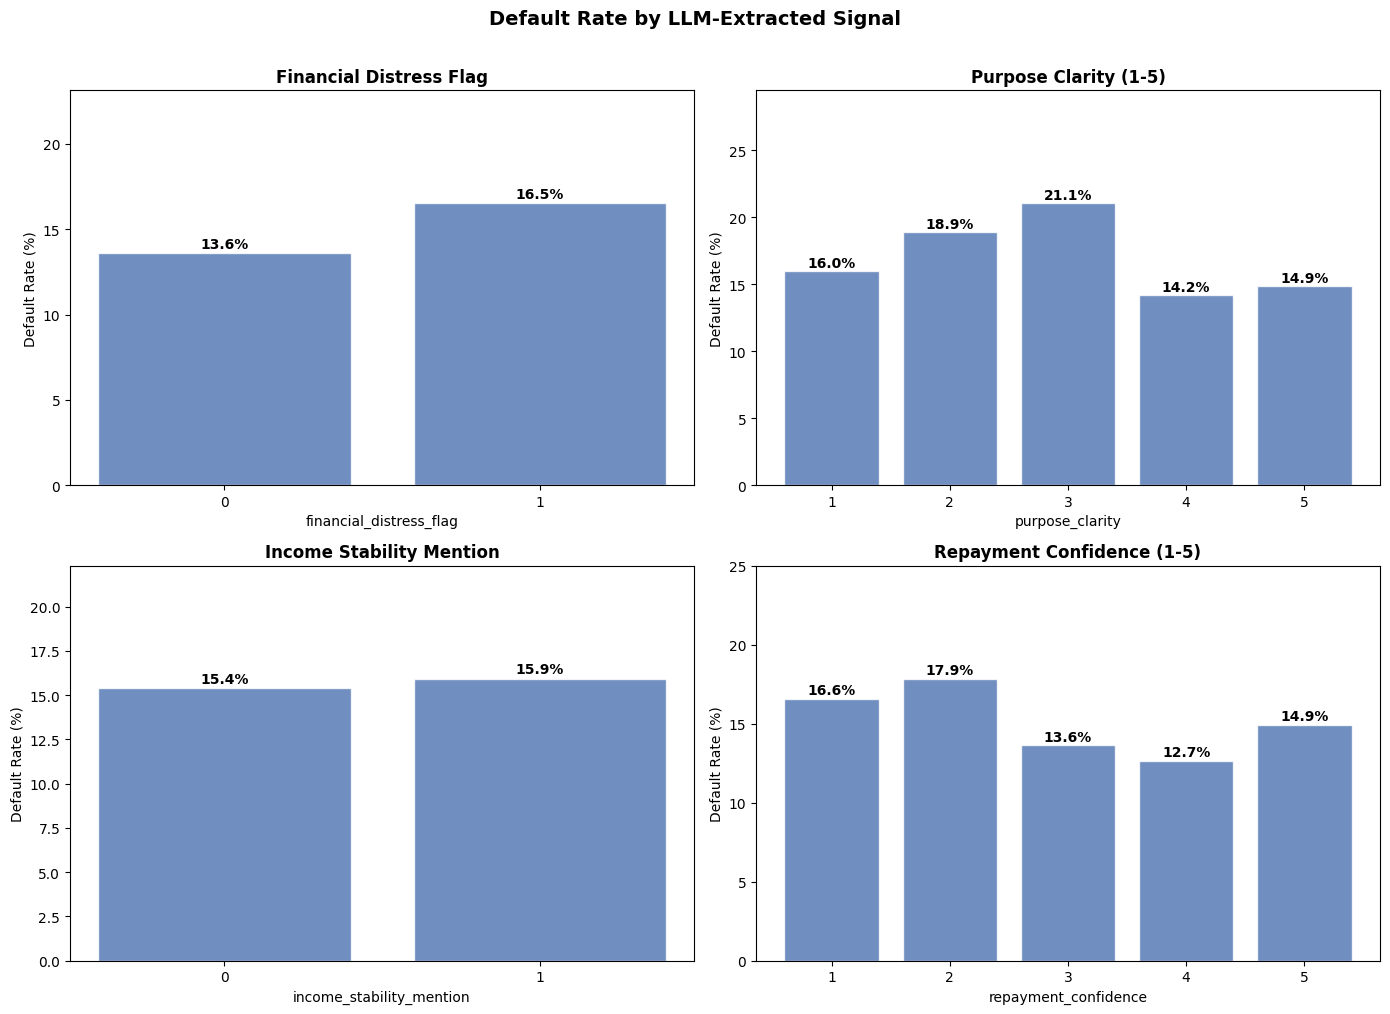


Saved → outputs/llm_signal_validation.png


In [22]:
import matplotlib.pyplot as plt

# Load completed batch
results_20k = pd.read_pickle("../data/processed/llm_signals_20k.pkl")

print(f"{'='*50}")
print(f"FULL BATCH SIGNAL VALIDATION")
print(f"{'='*50}")
print(f"Total extracted:  {len(results_20k):,}")
print(f"Default rate:     {results_20k['default_flag'].mean()*100:.1f}%")
print(f"Parse fail rate:  {(5000 - len(results_20k)) / 5000 * 100:.1f}%")

# ── Directional check ──────────────────────────────────────
print("\nDIRECTIONAL CHECK:")
print("-" * 50)
signals = ["financial_distress_flag", "purpose_clarity",
           "income_stability_mention", "repayment_confidence"]

for col in signals:
    d  = results_20k[results_20k["default_flag"] == 1][col].mean()
    nd = results_20k[results_20k["default_flag"] == 0][col].mean()
    if col == "financial_distress_flag":
        correct = d > nd
    else:
        correct = d < nd
    status = "✓" if correct else "✗ INVERTED"
    print(f"  {col:<30}  non-default: {nd:.3f}  default: {d:.3f}  {status}")

# Sentiment
print("\nSENTIMENT BY DEFAULT STATUS:")
print(pd.crosstab(results_20k["overall_sentiment"],
                  results_20k["default_flag"],
                  normalize="columns").round(3))

# ── Default rate by signal value ───────────────────────────
print("\nDEFAULT RATE BY SIGNAL VALUE:")
print("-" * 50)

print("\nfinancial_distress_flag:")
print(results_20k.groupby("financial_distress_flag")["default_flag"]
      .agg(["mean", "count"]).round(3).rename(columns={"mean": "default_rate"}))

print("\npurpose_clarity (1-5):")
print(results_20k.groupby("purpose_clarity")["default_flag"]
      .agg(["mean", "count"]).round(3).rename(columns={"mean": "default_rate"}))

print("\nrepayment_confidence (1-5):")
print(results_20k.groupby("repayment_confidence")["default_flag"]
      .agg(["mean", "count"]).round(3).rename(columns={"mean": "default_rate"}))

print("\nincome_stability_mention:")
print(results_20k.groupby("income_stability_mention")["default_flag"]
      .agg(["mean", "count"]).round(3).rename(columns={"mean": "default_rate"}))

print("\noverall_sentiment:")
print(results_20k.groupby("overall_sentiment")["default_flag"]
      .agg(["mean", "count"]).round(3).rename(columns={"mean": "default_rate"}))

# ── Plot default rate by signal ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(
    axes.flatten(),
    ["financial_distress_flag", "purpose_clarity",
     "income_stability_mention", "repayment_confidence"],
    ["Financial Distress Flag", "Purpose Clarity (1-5)",
     "Income Stability Mention", "Repayment Confidence (1-5)"]
):
    dr = results_20k.groupby(col)["default_flag"].mean() * 100
    ax.bar(dr.index.astype(str), dr.values, color="#4C72B0", alpha=0.8, edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Default Rate (%)")
    ax.set_ylim(0, dr.max() * 1.4)
    for x, v in zip(range(len(dr)), dr.values):
        ax.text(x, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Default Rate by LLM-Extracted Signal", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/llm_signal_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → outputs/llm_signal_validation.png")

In [23]:
import os
os.makedirs("../prompts", exist_ok=True)

prompt_text = EXTRACTION_PROMPT.replace("{{", "{").replace("}}", "}")
with open("../prompts/extraction_prompt.txt", "w") as f:
    f.write(prompt_text)

print("Saved → prompts/extraction_prompt.txt")

Saved → prompts/extraction_prompt.txt
